 # Project Title

### Talk2Table AI — Analyze Tables Using Natural Language Instead of SQL.

**Abstract**

**Talk2Table AI** is a multi-agent analytics chatbot that enables users to analyze any preprocessed CSV dataset using natural language instead of SQL. Users simply upload a preprocessed CSV file and ask questions in plain English, making data analysis accessible to both technical and non-technical users.

A **Router Agent** first classifies every user question into one of three categories:

* **Metadata Query** – Questions about the table structure, such as table name, column names, schema, row count, available fields, data types, or dataset overview.
* **SQL Query** – Questions that require analyzing the table contents, including filtering, aggregation, comparisons, rankings, trends, calculations, performance analysis, and data-driven insights.
* **Out-of-Scope Query** – Questions unrelated to the uploaded dataset or questions that cannot be answered using the available table information.

For SQL queries, the system leverages multiple AI agents to understand the dataset, generate and validate SQL queries, execute them safely, and provide meaningful insights. It also includes a **Visualization Agent** and **Chart Generator Agent** that automatically create charts such as bar, line, pie, and scatter plots, with support for PNG export. Built on LangGraph's multi-agent architecture, Talk2Table AI transforms natural language questions into actionable insights and visual analytics, making data exploration simple, intuitive, and user-friendly.



# 🚀 Talk2Table AI

### Transforming Natural Language into Data Insights and Visualizations

**Talk2Table AI** is an intelligent **multi-agent analytics chatbot** that enables users to analyze any preprocessed CSV dataset using **natural language instead of SQL**. Users simply upload a preprocessed CSV file and ask questions in plain English, making data analysis accessible even to non-technical users with no prior SQL knowledge.

## 🧠 Conversational Memory for Context-Aware Analytics

To provide a more natural and interactive user experience, Talk2Table AI includes a dedicated **Conversation Memory Agent** that maintains chat history and understands contextual follow-up questions.

This enables users to ask conversational queries such as:

**Q1:** Which manager generated the highest revenue?

**Q2:** What did he sell?

The Memory Agent intelligently rewrites ambiguous follow-up questions into complete, context-aware queries before passing them through the analytics pipeline, allowing users to interact with data naturally without repeatedly specifying details.

## 🔍 Intelligent Query Classification

A dedicated **Router Agent** automatically classifies every user question into one of three categories:

### 📋 Metadata Query

Questions about the table structure, such as:

* Table name
* Column names
* Schema information
* Row count
* Available fields
* Data types
* Dataset overview

### 📊 SQL Query

Questions that require analyzing the table contents, including:

* Filtering and searching
* Aggregations and calculations
* Comparisons and rankings
* Trend analysis
* Performance evaluation
* Data-driven insights

### 🚫 Out-of-Scope Query

Questions unrelated to the uploaded dataset or questions that cannot be answered using the available table information.

## ⚙️ Multi-Agent Analytics Pipeline

The system automatically ingests the uploaded dataset, creates a dynamic SQLite database, extracts schema information, and orchestrates a series of specialized AI agents to:

* Understand conversational context
* Resolve follow-up references using chat history
* Understand user intent
* Identify relevant columns
* Generate SQL queries
* Validate queries for safety and correctness
* Execute SQL operations
* Generate human-friendly responses

The integrated **Conversation Memory Agent** works alongside the analytics workflow to ensure that contextual questions are accurately interpreted before query generation begins.

## 📈 Intelligent Data Visualization

To enhance data exploration, Talk2Table AI includes a **Visualization Agent** and a **Chart Generator Agent** that automatically detect when users request graphical analysis.

The platform can generate:

* 📊 Bar Charts
* 📈 Line Charts
* 🥧 Pie Charts
* 🔵 Scatter Plots

Visualizations are automatically generated from the query results and can also be exported as **PNG files** for reporting and presentation purposes.

## 🎯 Key Features

✅ Dynamic preprocessed CSV Upload Support

✅ Natural Language to SQL Conversion

✅ Conversational Memory and Context Retention

✅ Context-Aware Follow-Up Question Handling

✅ Intelligent Column Understanding

✅ Metadata Retrieval

✅ SQL Validation and Safety Checks

✅ Automated Data Visualization

✅ PNG Chart Export

✅ Out-of-Scope Query Handling

✅ Conversational Analytics

## 🌟 Conclusion

Built using **LangGraph's Multi-Agent Architecture**, Talk2Table AI bridges the gap between complex database querying and everyday users by transforming natural language questions into actionable insights and interactive visualizations. By combining conversational memory, intelligent query understanding, automated SQL generation, and dynamic visualizations, the platform enables users to explore, analyze, and understand data effortlessly through a natural and intuitive chat experience, making analytics more accessible, context-aware, and user-friendly.



### Pictorial Representation Of WorkFlow Architechture

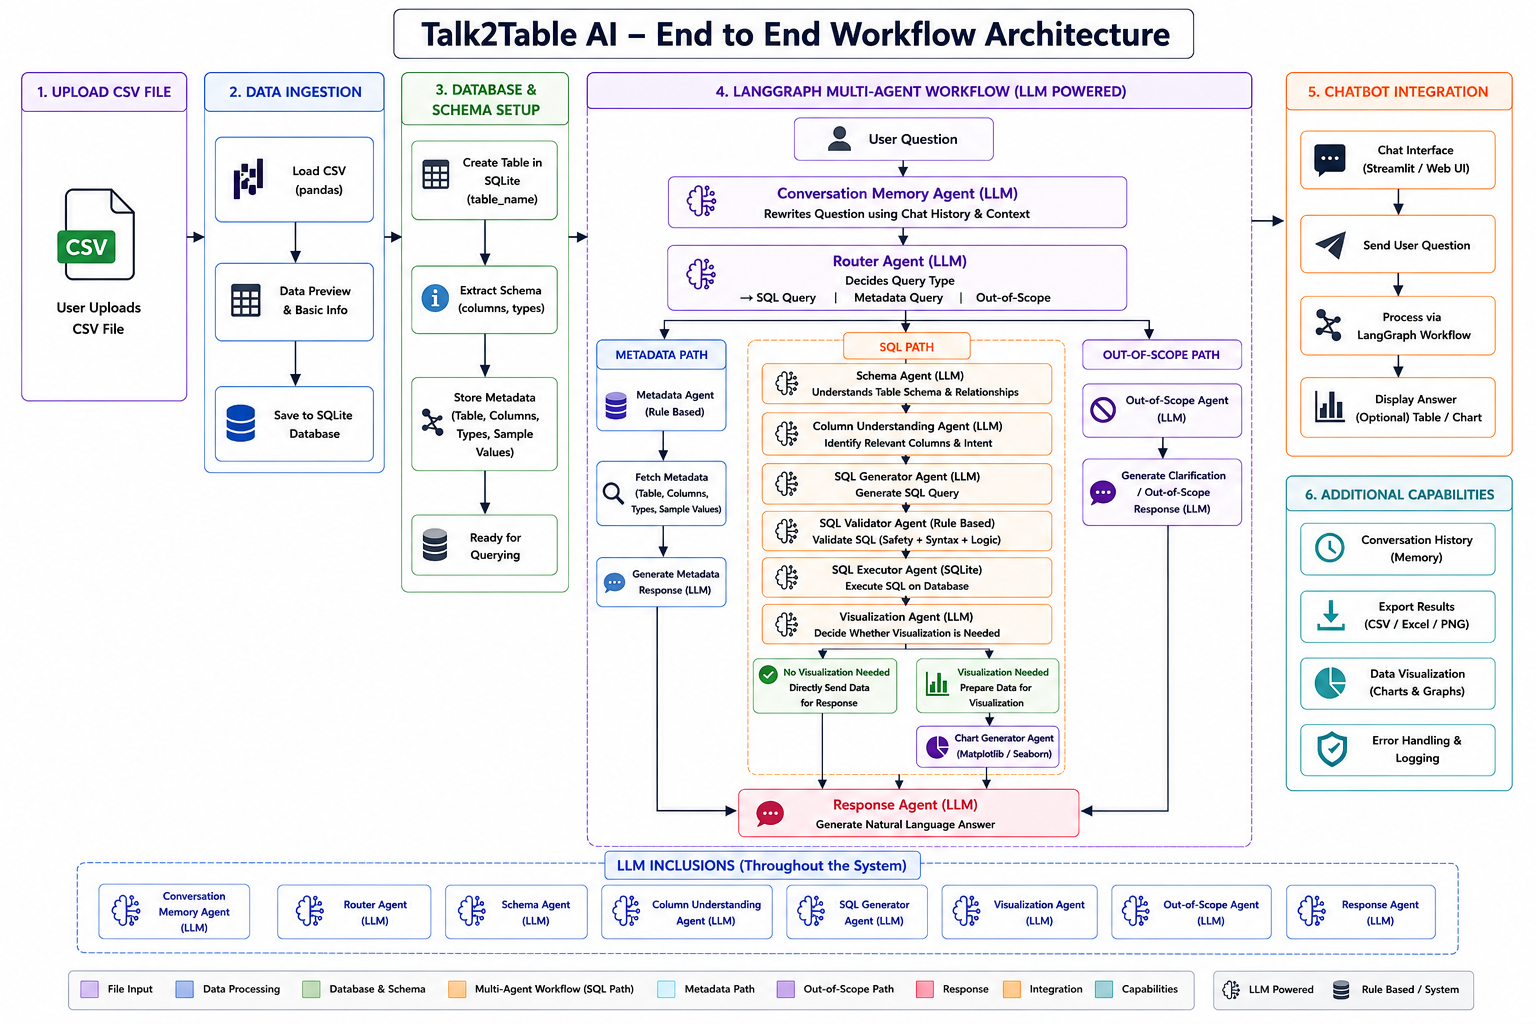

### Coding Part

In [1]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import os
import sqlite3
import pandas as pd

from dotenv import load_dotenv

from typing import TypedDict

from IPython.display import Image, display

#Matplotlib
import matplotlib.pyplot as plt


# LangChain
from langchain_openai import ChatOpenAI
from langchain.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# LangGraph
from langgraph.graph import (
    StateGraph,
    END
)

# Rich UI
from rich.console import Console
from rich.panel import Panel
from rich.table import Table
from rich import box

In [2]:
# =========================================================
# ENVIRONMENT VARIABLES
# =========================================================

load_dotenv(".env")

OPENAI_API_KEY = os.getenv(
    "OPENAI_API_KEY"
)

# =========================================================
# LLM
# =========================================================

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

# =========================================================
# CONSOLE
# =========================================================

console = Console()

console.print(
    Panel(
        "Text-to-SQL Chatbot Initialized",
        title="Chatbot Startup"
    )
)

╭──────────────────────────────────────────────── Chatbot Startup ────────────────────────────────────────────────╮
│ Text-to-SQL Chatbot Initialized                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [3]:
# =========================================================
# LOAD USER CSV FILE
# =========================================================

import os

CSV_FILE = input(
    "\nEnter CSV file path: "
).strip()

if not CSV_FILE.lower().endswith(
    ".csv"
):
    raise ValueError(
        "Only CSV files are supported."
    )

# =========================================================
# TABLE NAME
# =========================================================

TABLE_NAME = os.path.splitext(
    os.path.basename(CSV_FILE)
)[0]

TABLE_TITLE = " ".join(
    word.capitalize()
    for word in TABLE_NAME.replace("_"," ").split()
)

# =========================================================
# LOAD CSV
# =========================================================

df = pd.read_csv(
    CSV_FILE
)

console.print(
    f"\nRows : {df.shape[0]}"
)

console.print(
    f"Columns : {df.shape[1]}"
)

# =========================================================
# CREATE SQLITE DATABASE
# =========================================================

DB_NAME = (
    f"{TABLE_TITLE}.db"
)

conn = sqlite3.connect(
    DB_NAME
)

df.to_sql(
    name=TABLE_NAME,
    con=conn,
    if_exists="replace",
    index=False
)

# =========================================================
# CHATBOT STARTUP MESSAGE
# =========================================================

def show_welcome_message():

    console.print(

        Panel(

            f"Welcome to {TABLE_TITLE} Analyser Chatbot",

            title="Analyser Chatbot",

            border_style="green"

        )

    )

console.print(
    f"\nTable '{TABLE_NAME}' created successfully."
)

show_welcome_message()


Enter CSV file path:  /Users/viswanathanmuthu/AI Course/Agentic AI Application/Talk2Table AI Applctn/sample_sales_table.csv


Rows : 5

Columns : 10

Table 'sample_sales_table' created successfully.

╭─────────────────────────────────────────────── Analyser Chatbot ────────────────────────────────────────────────╮
│ Welcome to Sample Sales Table Analyser Chatbot                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [4]:
cursor = conn.cursor()

cursor.execute(
    "SELECT name FROM sqlite_master WHERE type='table';"
)

print(cursor.fetchall())

[('sample_sales_table',)]


In [5]:
# =========================================================
# STATE
# =========================================================

class SQLState(TypedDict):

    # User Input
    question: str

    # Memory
    enhanced_question: str
    chat_history: list

    # Routing
    query_type: str

    # Schema Understanding
    schema: str
    column_context: str

    # SQL Generation
    sql_query: str

    # Visualization Planning
    is_visualization: bool
    chart_type: str
    x_axis: str
    y_axis: str
    group_by: str

    # SQL Execution Output
    result_df: pd.DataFrame

    # Chart Output
    chart_file: str

    # Final Response
    final_answer: str

In [6]:
# =========================================================
# CONVERSATION MEMORY AGENT
# =========================================================

def conversation_memory_agent(
    state: SQLState
):

    console.print(
        "\n[bold yellow]Conversation Memory Agent Running[/bold yellow]"
    )

    question = state[
        "question"
    ].strip()

    chat_history = state[
        "chat_history"
    ]


    # =====================================================
    # SMART MEMORY ACTIVATION
    # =====================================================

    strong_reference_words = [

        "he",
        "she",
        "it",
        "they",
        "them",
        "his",
        "her",
        "their",
        "this",
        "that",
        "these",
        "those",
        "former",
        "latter"

    ]

    weak_reference_phrases = [

        "who",
        "what",
        "where",
        "when",
        "which",
        "how much",
        "how many"

    ]

    question_lower = question.lower()

    has_strong_reference = any(

        word in question_lower.split()

        for word in strong_reference_words

    )

    has_weak_reference = any(

        phrase in question_lower

        for phrase in weak_reference_phrases

    )

    is_short_question = (

        len(
            question_lower.split()
        ) <= 5

    )

    memory_required = (

        has_strong_reference

        or

        (

            len(chat_history) > 0

            and has_weak_reference

            and is_short_question

        )

    )

    if not memory_required:

        state[
            "enhanced_question"
        ] = question

        console.print(
            "[green]Memory Not Required[/green]"
        )

        console.print(

            Panel(

                question,

                title="Enhanced Question"

            )

        )

        return state

    # =====================================================
    # No previous history available
    # =====================================================

    if len(chat_history) == 0:

        state[
            "enhanced_question"
        ] = question

        console.print(
            "[green]No Previous History Found[/green]"
        )

        return state

    # =====================================================
    # Use only recent conversations
    # =====================================================

    recent_history = chat_history[-3:]

    history_text = ""

    for i, chat in enumerate(

        recent_history,

        start=1

    ):

        history_text += f"""

Question {i}:
{chat['question']}

Answer {i}:
{chat['answer']}

"""

    prompt = PromptTemplate.from_template(
        """
You are a Conversation Memory Agent.

Your task is to rewrite the current
question using previous conversation
history ONLY when necessary.

Conversation History:

{history}

Current Question:

{question}

Rules:

1. Only use conversation history when
   the current question contains an
   explicit reference to a previous
   answer.

2. Explicit references include:

   he
   she
   it
   they
   them
   his
   her
   their
   this
   that
   these
   those
   former
   latter

3. Short follow-up questions may also
   depend on conversation history,
   for example:

   who sold them

   what about the second one

   where was it sold

   how much was sold

   how many were sold

4. Use conversation history only when
   required to resolve ambiguity.

5. If the current question is already
   complete and self-contained,
   return it unchanged.

6. Do NOT infer new intentions.

7. Do NOT introduce new topics.

8. Do NOT combine multiple previous
   conversations.

9. Preserve the user's original intent.

10. Do NOT answer the question.

11. Only rewrite the question.

12. If no rewrite is required,
    return the original question.

Examples:

History:

Q: Which item has the highest value?

A: Item A has the highest value.

Question:

What category does it belong to?

Rewrite:

What category does Item A belong to?


History:

Q: Which record ranks first?

A: Record X ranks first.

Question:

What are its details?

Rewrite:

What are the details of Record X?


History:

Q: Show analysis by category.

A: Analysis displayed by category.

Question:

Show it as a chart.

Rewrite:

Show analysis by category as a chart.


History:

Q: Compare the top performer.

A: Entity Y is the top performer.

Question:

What about the second one?

Rewrite:

Compare Entity Y with the second-ranked entity.

Return ONLY the rewritten question.
"""
    )

    chain = (

        prompt
        | llm
        | StrOutputParser()

    )

    enhanced_question = chain.invoke({

        "history": history_text,

        "question": question

    }).strip()

    if not enhanced_question:

        enhanced_question = question

    state[
        "enhanced_question"
    ] = enhanced_question

    console.print(

        Panel(

            enhanced_question,

            title="Enhanced Question"

        )

    )

    return state

In [7]:
# =========================================================
# ROUTER AGENT
# =========================================================

def router_agent(state: SQLState):

    console.print(
        "\n[bold cyan]Router Agent Running[/bold cyan]"
    )

    columns = list(df.columns)

    prompt = PromptTemplate.from_template(
        """
You are a query routing agent.

Available Columns:

{columns}

User Question:

{enhanced_question}

Classify the question into ONLY ONE category:

metadata
sql
out_of_scope

Definitions:

metadata:

- asks table name
- asks dataset name
- asks column names
- asks available fields
- asks schema
- asks data types
- asks table structure
- asks number of rows
- asks number of columns
- asks dataset overview
- asks general information about the structure of the table

sql:

- requires reading data from the table
- requires retrieving values stored in rows
- requires retrieving information from one or more columns
- requires displaying records
- requires showing entries
- requires retrieving actual data values
- requires listing values present in the dataset
- requires listing unique values
- requires data retrieval
- requires filtering
- requires aggregation
- requires comparison
- requires ranking
- requires calculations
- requires trend analysis
- requires performance analysis
- requires identifying top or bottom performers
- requires summaries or insights from table contents
- requires answering questions using the data stored in the table
- requires analyzing actual table contents
- refers directly or indirectly to table columns
- requires finding relationships between columns
- requires sorting or ordering results
- requires grouping data
- requires statistical analysis

out_of_scope:

- unrelated to the uploaded table
- unrelated to the dataset contents
- cannot be answered using the available table data
- general knowledge questions
- current affairs
- news and recent events
- science and technology topics not present in the dataset
- politics and political discussions
- sports topics not present in the dataset
- entertainment topics not present in the dataset
- history questions not answerable from the dataset
- geography questions not answerable from the dataset
- mathematical problems unrelated to the dataset
- programming or coding questions unrelated to the dataset
- health and medical questions unrelated to the dataset
- legal or financial advice unrelated to the dataset
- philosophical or opinion-based questions
- personal advice requests
- creative writing requests
- story generation requests
- translation requests
- email, letter, or document writing requests
- questions about people, places, organizations, or events not contained in the dataset
- hypothetical questions not based on the dataset
- requests requiring external knowledge beyond the uploaded table
- questions whose answers cannot be derived from the table structure or table contents
Return ONLY ONE WORD:

metadata

OR

sql

OR

out_of_scope
"""
    )

    chain = (
        prompt
        | llm
        | StrOutputParser()
    )

    query_type = chain.invoke({

        "columns": columns,

        "enhanced_question": state["enhanced_question"]

    }).strip().lower()

    if query_type not in [

        "metadata",

        "sql",

        "out_of_scope"

    ]:

        query_type = (
            "out_of_scope"
        )

    state["query_type"] = (
        query_type
    )

    console.print(
        f"[green]Route → {query_type}[/green]"
    )

    return state

In [8]:
# =========================================================
# METADATA AGENT
# =========================================================

def metadata_agent(state: SQLState):

    console.print(
        "\n[bold green]Metadata Agent Running[/bold green]"
    )

    question = (
        state["enhanced_question"]
        .strip()
        .lower()
    )

    columns = list(df.columns)

    if (
        "table name" in question
        or "dataset name" in question
    ):

        answer = (
            f"Table Name : {TABLE_NAME}"
        )

    elif (
        "column" in question
        or "field" in question
        or "schema" in question
    ):

        answer = (
            "Available Columns:\n\n"
            + "\n".join(
                f"• {col}"
                for col in columns
            )
        )

    elif (
        "how many columns" in question
    ):

        answer = (
            f"Number of Columns : "
            f"{len(columns)}"
        )

    elif (
        "how many rows" in question
    ):

        answer = (
            f"Number of Rows : "
            f"{len(df)}"
        )

    else:

        answer = (
            f"Table Name : {TABLE_NAME}\n\n"
            f"Rows : {df.shape[0]}\n"
            f"Columns : {df.shape[1]}\n\n"
            f"Available Columns:\n"
            + "\n".join(
                f"• {col}"
                for col in columns
            )
        )

    state["final_answer"] = (
        answer
    )

    return state

In [9]:
# =========================================================
# OUT OF SCOPE AGENT
# =========================================================

def out_of_scope_agent(state: SQLState):

    console.print(
        "\n[bold red]Out Of Scope Agent Running[/bold red]"
    )

    columns = list(df.columns)

    state["final_answer"] = f"""
I can answer questions only from the uploaded table.

Table Name:
{TABLE_NAME}

Available Columns:

{', '.join(columns)}

Please ask questions related to these columns.
"""

    return state

In [10]:
# =========================================================
# SCHEMA AGENT
# =========================================================

def schema_agent(state: SQLState):

    console.print(
        "\n[bold yellow]Schema Agent Running[/bold yellow]"
    )

    cursor = conn.cursor()

    cursor.execute(
        f"PRAGMA table_info({TABLE_NAME})"
    )

    columns_info = cursor.fetchall()

    schema = []

    for column in columns_info:

        col_name = column[1]

        col_type = column[2]

        schema.append(
            f"{col_name} ({col_type})"
        )

    schema_text = (
        f"Table Name : {TABLE_NAME}\n\n"
        + "\n".join(schema)
    )

    state["schema"] = schema_text

    console.print(
        Panel(
            schema_text,
            title="Table Schema"
        )
    )

    return state

In [11]:
# =========================================================
# COLUMN UNDERSTANDING AGENT
# =========================================================

def column_understanding_agent(
    state: SQLState
):

    console.print(
        "\n[bold magenta]Column Understanding Agent Running[/bold magenta]"
    )

    enhanced_question = state[
        "enhanced_question"
    ]

    columns = list(
        df.columns
    )

    # =====================================================
    # DYNAMIC SAMPLE VALUES
    # =====================================================

    sample_values_text = ""

    for col in df.columns:

        samples = (

            df[col]
            .dropna()
            .astype(str)
            .unique()[:5]

        )

        sample_values_text += f"""

{col}:

{', '.join(samples)}

"""

    prompt = PromptTemplate.from_template(
        """
You are an expert database analyst and business analyst.

Table Schema:

{schema}

User Question:

{enhanced_question}

Available Columns:

{columns}

Sample Values From Dataset:

{sample_values}

Your job:

1. Study all available columns.

2. Understand the user's intent.

3. Identify which columns are relevant.

4. Infer semantic meaning.

5. User may not use exact column names.

6. Match user terminology to the closest
   matching column names or sample values.

7. Use semantic understanding instead of
   exact keyword matching.

8. Consider both column names and sample values.

9. Identify possible aggregations.

10. Identify possible ranking/filtering logic.

11. Infer business meaning from the data.

Examples:

Question:
Which product generated highest revenue?

Output:

Relevant Columns:
Product_Name
Revenue

Intent:
Find highest revenue product

Business Mapping:
None


Question:
Who performs best?

Output:

Relevant Columns:
Manager
Revenue

Intent:
Find best-performing manager

Business Mapping:
performs best → highest revenue


Question:
What gadgets were sold in north?

Dataset Values:

Category:
Electronics
Furniture
Appliances

Region:
North
South

Output:

Relevant Columns:
Category
Region
Product_Name

Intent:
Find products sold in North region
belonging to Electronics category

Business Mapping:
gadgets → Electronics


Question:
Show premium items.

Dataset Values:

Category:
Premium
Standard
Economy

Output:

Relevant Columns:
Category

Intent:
Show Premium category records

Business Mapping:
premium items → Premium

Return ONLY in the following format:

Relevant Columns:

Column1
Column2
Column3

Intent:

<clear interpretation of user request>

Business Mapping:

<mappings identified>

If no mappings exist:

Business Mapping:

None
"""
    )

    chain = (

        prompt
        | llm
        | StrOutputParser()

    )

    column_context = chain.invoke({

        "schema": state["schema"],

        "enhanced_question": enhanced_question,

        "columns": "\n".join(
            columns
        ),

        "sample_values": sample_values_text

    })

    state[
        "column_context"
    ] = column_context

    console.print(

        Panel(

            column_context,

            title="Column Understanding"

        )

    )

    return state

In [12]:
# =========================================================
# SQL GENERATOR AGENT
# =========================================================

def sql_generator_agent(state: SQLState):

    console.print(
        "\n[bold cyan]SQL Generator Agent Running[/bold cyan]"
    )

    prompt = PromptTemplate.from_template(
        """
You are an expert senior SQLite SQL Generator.

Table Schema:

{schema}

Column Understanding:

{column_context}

User Question:

{enhanced_question}

Rules:

1. Use ONLY the table:
   {table_name}

2. Use ONLY columns present in the schema.

3. Generate ONLY SQLite-compatible SQL.

4. Return ONLY SQL query.

5. Do NOT return:
   - explanations
   - markdown
   - comments
   - code fences
   - notes
   - reasoning

6. Do NOT use:
   - regular expressions
   - REGEXP
   - Python code
   - pseudocode

7. Always generate executable SQL.

8. If aggregation is requested:
   Use COUNT, SUM, AVG, MIN, MAX.

9. If sorting is required:
   Use ORDER BY.

10. If top records are requested:
    Use LIMIT.

11. If filtering is required:
    Use WHERE.

12. If grouping is required:
    Use GROUP BY.

13. If the question refers to a column indirectly,
    infer the correct column from schema.

14. If multiple columns have similar meaning,
    choose the most relevant one.

15. Column names must exactly match schema.

16. Never invent:
    - tables
    - columns
    - values

17. If question cannot be answered from schema,
    return exactly:

    INVALID_QUERY

18. If user asks:
    - all records
    - show dataset
    - display table
    - show data

    generate:

    SELECT * FROM {table_name};

19. If user asks row count:

    SELECT COUNT(*) FROM {table_name};

20. SQL must end with semicolon.

Return ONLY SQL.
"""
    )

    chain = (
        prompt
        | llm
        | StrOutputParser()
    )

    sql_query = chain.invoke({

        "schema": state["schema"],
    
        "column_context": state[
            "column_context"
        ],
    
        "enhanced_question": state["enhanced_question"],
    
        "table_name": TABLE_NAME
    
    })
    sql_query = sql_query.strip()

    state["sql_query"] = sql_query

    console.print(
        Panel(
            sql_query,
            title="Generated SQL"
        )
    )

    return state

In [13]:
# =========================================================
# SQL VALIDATOR AGENT
# =========================================================

def sql_validator_agent(
    state: SQLState
):

    console.print(
        "\n[bold green]SQL Validator Agent Running[/bold green]"
    )

    sql_query = (
        state["sql_query"]
        .replace("```sql", "")
        .replace("```", "")
        .strip()
    )

    if not sql_query:

        state["final_answer"] = (
            "No SQL query generated."
        )

        return state

    if sql_query == "INVALID_QUERY":

        state["final_answer"] = f"""
Unable to generate a valid SQL query.

Please ask questions related to:

{', '.join(df.columns)}
"""

        return state

    dangerous_keywords = [

        "DROP",
        "DELETE",
        "TRUNCATE",
        "ALTER",
        "UPDATE",
        "INSERT",
        "CREATE",
        "REPLACE",
        "ATTACH",
        "DETACH",
        "PRAGMA"

    ]

    upper_sql = sql_query.upper()

    for keyword in dangerous_keywords:

        if keyword in upper_sql:

            state["final_answer"] = (
                "Unsafe SQL detected."
            )

            state["sql_query"] = ""

            return state

    if TABLE_NAME.lower() not in (
        upper_sql.lower()
    ):

        state["final_answer"] = (
            "Generated SQL does not use the uploaded table."
        )

        state["sql_query"] = ""

        return state

    try:

        validation_query = f"""

        SELECT *
        FROM (
            {sql_query.rstrip(';')}
        )
        LIMIT 1

        """

        pd.read_sql_query(
            validation_query,
            conn
        )

    except Exception as e:

        state["final_answer"] = (
            f"SQL Validation Failed: {str(e)}"
        )

        state["sql_query"] = ""

        return state

    state["sql_query"] = sql_query

    console.print(
        "[green]SQL Validation Passed[/green]"
    )

    console.print(
        f"\nValidated SQL:\n{sql_query}"
    )

    return state

In [14]:
# =========================================================
# SQL EXECUTOR AGENT
# =========================================================

def sql_executor_agent(state: SQLState):

    console.print(
        "\n[bold blue]SQL Executor Agent Running[/bold blue]"
    )

    console.print(
        f"\nSQL Received By Executor:\n{state['sql_query']}"
    )
    

    sql_query = (
        state["sql_query"]
        .strip()
    )

    if not sql_query:

        console.print(
            "[red]No SQL Query Found[/red]"
        )

        return state

    try:

        result_df = pd.read_sql_query(
            sql_query,
            conn
        )

        state["result_df"] = (
            result_df
        )

        console.print(

            Panel(

                f"Rows Returned : {len(result_df)}\n"
                f"Columns Returned : {len(result_df.columns)}",

                title="SQL Execution Summary"

            )

        )

        if not result_df.empty:

            preview_table = Table(
                title="Query Result Preview",
                box=box.DOUBLE_EDGE
            )

            for col in result_df.columns:

                preview_table.add_column(
                    str(col)
                )

            preview_rows = min(
                len(result_df),
                10
            )

            for _, row in (
                result_df
                .head(preview_rows)
                .iterrows()
            ):

                preview_table.add_row(

                    *[
                        str(value)
                        for value in row
                    ]

                )

            console.print(
                preview_table
            )

        else:

            console.print(

                "[yellow]Query executed successfully but returned no records.[/yellow]"

            )

    except Exception as e:

        state["final_answer"] = (
            f"SQL Execution Failed : {str(e)}"
        )

        state["result_df"] = (
            pd.DataFrame()
        )

        console.print(

            Panel(

                str(e),

                title="SQL Execution Error",

                border_style="red"

            )

        )
    
    return state
    

In [15]:
# =========================================================
# VISUALIZATION AGENT
# =========================================================

def visualization_agent(
    state: SQLState
):

    console.print(
        "\n[bold magenta]Visualization Agent Running[/bold magenta]"
    )

    question = state[
        "enhanced_question"
    ]

    result_df = state[
        "result_df"
    ]

    if result_df.empty:

        state[
            "is_visualization"
        ] = False

        return state

    prompt = PromptTemplate.from_template(
    """
You are an expert Data Visualization Planner.

User Question:

{enhanced_question}

Available Columns:

{columns}

Your task is to determine:

1. Whether visualization is required.
2. Which chart type is most suitable.
3. Which column should be X-axis.
4. Which column should be Y-axis.
5. Whether a grouping column is required.

Visualization Detection Rules:

Questions containing words such as:

graph
chart
plot
visualize
visualization
dashboard
pictorial
trend

should be treated as visualization requests.

Chart Selection Rules:

1. Time or Date based analysis
   -> line chart

2. Category vs Numeric analysis
   -> bar chart

3. Share, percentage, composition,
   distribution
   -> pie chart

4. Relationship between two numeric columns
   -> scatter chart

Axis Selection Rules:

1. Choose ONE categorical column
   as X-axis.

2. Choose ONE numeric column
   as Y-axis.

3. If another categorical column
   helps comparison,
   use it as Group By.

4. For Date/Time analysis:

   X-axis = Date/Time column

   Y-axis = Relevant numeric column

   Chart = line

5. For two numeric columns:

   Chart = scatter

6. If multiple numeric columns exist:

   Select the numeric column
   most relevant to the user's question.

7. If multiple categorical columns exist:

   Select the primary category
   mentioned in the user's question
   as X-axis.

   Select the secondary category
   as Group By.

8. If no grouping is needed:

   group_by = None

Examples:

Example 1

Columns:
Category, Numeric

Result:

X-axis = Category

Y-axis = Numeric

Group By = None

Chart = bar


Example 2

Columns:
Category, Numeric, Category

Result:

X-axis = Primary Category

Y-axis = Numeric

Group By = Secondary Category

Chart = bar


Example 3

Columns:
Date, Numeric

Result:

X-axis = Date

Y-axis = Numeric

Group By = None

Chart = line


Example 4

Columns:
Numeric, Numeric

Result:

X-axis = First Numeric

Y-axis = Second Numeric

Group By = None

Chart = scatter

Important:

- Use ONLY column names from Available Columns.
- Never invent column names.
- Choose the columns that best answer the user's question.
- Return exactly in the format shown below.
- Do not provide explanations.

Return ONLY:

visualization=yes
chart_type=bar
x_axis=<column_name>
y_axis=<column_name>
group_by=<column_name_or_None>

OR

visualization=no
chart_type=None
x_axis=None
y_axis=None
group_by=None
"""
    )
    
    chain = (

        prompt
        | llm
        | StrOutputParser()

    )

    response = chain.invoke({

        "enhanced_question": question,

        "columns": list(
            result_df.columns
        )

    })

    visualization = False
    chart_type = ""
    x_axis = ""
    y_axis = ""
    group_by = ""

    for line in response.splitlines():

        line = line.strip()

        if "=" not in line:

            continue

        key, value = line.split(
            "=",
            1
        )

        key = key.strip().lower()

        value = value.strip()

        if key == "visualization":

            visualization = (
                value.lower() == "yes"
            )

        elif key == "chart_type":

            chart_type = value

        elif key == "x_axis":

            x_axis = value

        elif key == "y_axis":

            y_axis = value

        elif key == "group_by":

            if value.lower() != "none":

                group_by = value

    valid_columns = {

        col.lower(): col

        for col in result_df.columns

    }

    if x_axis.lower() in valid_columns:

        x_axis = valid_columns[
            x_axis.lower()
        ]

    else:

        x_axis = result_df.columns[0]

    if y_axis.lower() in valid_columns:

        y_axis = valid_columns[
            y_axis.lower()
        ]

    else:

        numeric_cols = result_df.select_dtypes(
            include="number"
        ).columns

        if len(numeric_cols):

            y_axis = numeric_cols[0]

        else:

            y_axis = result_df.columns[-1]

    if (

        group_by
        and group_by.lower()
        in valid_columns

    ):

        group_by = valid_columns[
            group_by.lower()
        ]

    else:

        group_by = ""

    if chart_type not in [

        "bar",
        "line",
        "pie",
        "scatter"

    ]:

        chart_type = "bar"

    state[
        "is_visualization"
    ] = visualization

    state[
        "chart_type"
    ] = chart_type

    state[
        "x_axis"
    ] = x_axis

    state[
        "y_axis"
    ] = y_axis

    state[
        "group_by"
    ] = group_by

    console.print(

        Panel(

            f"""
Chart Type : {chart_type}

X Axis : {x_axis}

Y Axis : {y_axis}

Group By : {group_by if group_by else 'None'}
""",

            title="Visualization Plan"

        )

    )

    return state

In [16]:
# =========================================================
# CHART GENERATOR AGENT
# =========================================================

def chart_generator_agent(
    state: SQLState
):

    console.print(
        "\n[bold blue]Chart Generator Agent Running[/bold blue]"
    )

    if not state[
        "is_visualization"
    ]:

        return state

    result_df = state[
        "result_df"
    ]

    if result_df.empty:

        state[
            "final_answer"
        ] = (
            "No data available for visualization."
        )

        return state

    chart_type = state[
        "chart_type"
    ]

    x_col = state[
        "x_axis"
    ]

    y_col = state[
        "y_axis"
    ]

    group_col = state[
        "group_by"
    ]

    if (
        x_col not in result_df.columns
        or
        y_col not in result_df.columns
    ):

        state[
            "final_answer"
        ] = (
            "Unable to identify suitable "
            "columns for visualization."
        )

        return state

    plt.figure(
        figsize=(12, 6)
    )

    # =====================================================
    # BAR CHART
    # =====================================================

    if chart_type == "bar":

        colors = plt.cm.tab20.colors

        if group_col and group_col in result_df.columns:

            pivot_df = result_df.pivot_table(
                index=x_col,
                columns=group_col,
                values=y_col,
                aggfunc="sum"
            )

            pivot_df.plot(
                kind="bar",
                figsize=(12, 6),
                colormap="tab20"
            )

        else:

            plt.bar(
                result_df[x_col],
                result_df[y_col],
                color=colors[:len(result_df)]
            )

    # =====================================================
    # LINE CHART
    # =====================================================

    elif chart_type == "line":

        colors = plt.cm.tab20.colors

        if (
            group_col
            and
            group_col in result_df.columns
        ):

            for i, (
                group,
                group_df
            ) in enumerate(

                result_df.groupby(
                    group_col
                )

            ):

                plt.plot(
                    group_df[x_col],
                    group_df[y_col],
                    label=str(group),
                    color=colors[
                        i % len(colors)
                    ],
                    marker="o",
                    linewidth=2
                )

            plt.legend()

        else:

            plt.plot(
                result_df[x_col],
                result_df[y_col],
                color=plt.cm.Dark2(0),
                marker="o",
                linewidth=2
            )

    # =====================================================
    # PIE CHART
    # =====================================================

    elif chart_type == "pie":

        colors = plt.cm.Set3.colors

        plt.pie(
            result_df[y_col],
            labels=result_df[x_col],
            colors=colors[
                :len(result_df)
            ],
            autopct="%1.1f%%"
        )

    # =====================================================
    # SCATTER CHART
    # =====================================================

    elif chart_type == "scatter":

        plt.scatter(
            result_df[x_col],
            result_df[y_col],
            c=range(
                len(result_df)
            ),
            cmap="tab10",
            s=100
        )

    # =====================================================
    # COMMON FORMATTING
    # =====================================================

    plt.title(
        state["question"]
    )

    plt.xlabel(
        x_col
    )

    plt.ylabel(
        y_col
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()

    chart_file = (
        f"{TABLE_TITLE}_chart.png"
    )

    plt.savefig(
        chart_file,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    state[
        "chart_file"
    ] = chart_file

    console.print(

        f"[green]Chart Saved : "
        f"{chart_file}[/green]"

    )

    return state

In [17]:
# =========================================================
# RESPONSE AGENT
# =========================================================

def response_agent(state: SQLState):

    console.print(
        "\n[bold magenta]Response Agent Running[/bold magenta]"
    )

    result_df = state["result_df"]

    if result_df is None:

        state["final_answer"] = (
            "No result available."
        )

        return state

    if result_df.empty:

        state["final_answer"] = (
            "No records found."
        )

        return state

    # ------------------------------------------
    # Single Value Result
    # ------------------------------------------

    if (
        result_df.shape[0] == 1
        and result_df.shape[1] == 1
    ):

        value = result_df.iloc[0, 0]

        state["final_answer"] = str(
            value
        )

        return state

# ------------------------------------------
# Tabular Result Formatting
# ------------------------------------------

    MAX_DISPLAY_ROWS = 10
    
    if len(result_df) <= MAX_DISPLAY_ROWS:
    
        state["final_answer"] = (
            result_df.to_string(
                index=False
            )
        )
    
    else:
    
        state["final_answer"] = (
    
            f"Showing first "
            f"{MAX_DISPLAY_ROWS} rows out of "
            f"{len(result_df)} rows.\n\n"
    
            f"{result_df.head(MAX_DISPLAY_ROWS).to_string(index=False)}"
    
        )
    
    return state

In [18]:
# =========================================================
# BUILD LANGGRAPH WORKFLOW
# =========================================================

builder = StateGraph(SQLState)

# ------------------------------------------
# Register Nodes
# ------------------------------------------

builder.add_node(
    "Memory",
    conversation_memory_agent
)

builder.add_node(
    "Router",
    router_agent
)

builder.add_node(
    "Metadata",
    metadata_agent
)

builder.add_node(
    "OutOfScope",
    out_of_scope_agent
)

builder.add_node(
    "Schema",
    schema_agent
)

builder.add_node(
    "ColumnUnderstanding",
    column_understanding_agent
)

builder.add_node(
    "SQLGenerator",
    sql_generator_agent
)

builder.add_node(
    "SQLValidator",
    sql_validator_agent
)

builder.add_node(
    "SQLExecutor",
    sql_executor_agent
)

builder.add_node(
    "Visualization",
    visualization_agent
)

builder.add_node(
    "ChartGenerator",
    chart_generator_agent
)

builder.add_node(
    "Response",
    response_agent
)

# ------------------------------------------
# Entry Point
# ------------------------------------------

builder.set_entry_point(
    "Memory"
)

In [19]:
# =========================================================
# ROUTING FUNCTION
# =========================================================

# Route Question

def route_question(state: SQLState):

    """
    Reads the route assigned by Router Agent
    and returns the next node name for LangGraph.
    """

    query_type = (
        state["query_type"]
        .strip()
        .lower()
    )

    valid_routes = {

        "metadata",
        "sql",
        "out_of_scope"

    }

    if query_type not in valid_routes:

        console.print(

            "[red]Invalid Route Detected[/red]"

        )

        return "out_of_scope"

    return query_type

    
#Route Visualization

def route_visualization(
    state: SQLState
):

    question = state[
        "question"
    ].lower()

    visualization_keywords = [

        "graph",
        "chart",
        "plot",
        "visualize",
        "visualization",
        "dashboard",
        "trend",
        "pictorial"

    ]

    for keyword in visualization_keywords:

        if keyword in question:

            return "visualization"

    return "response"


In [20]:
# ------------------------------------------
# Adding Edges
# ------------------------------------------

builder.add_edge(
    "Memory",
    "Router"
)

# ------------------------------------------
# Conditional Routing
# ------------------------------------------

builder.add_conditional_edges(

    "Router",

    route_question,

    {

        "metadata": "Metadata",

        "sql": "Schema",

        "out_of_scope": "OutOfScope"

    }

)

# ------------------------------------------
# Metadata Path
# ------------------------------------------

builder.add_edge(
    "Metadata",
    END
)

# ------------------------------------------
# Out Of Scope Path
# ------------------------------------------

builder.add_edge(
    "OutOfScope",
    END
)

# ------------------------------------------
# SQL Workflow Path
# ------------------------------------------

builder.add_edge(
    "Schema",
    "ColumnUnderstanding"
)

builder.add_edge(
    "ColumnUnderstanding",
    "SQLGenerator"
)
builder.add_edge(
    "SQLGenerator",
    "SQLValidator"
)

builder.add_edge(
    "SQLValidator",
    "SQLExecutor"
)

builder.add_conditional_edges(

    "SQLExecutor",

    route_visualization,

    {

        "visualization":
            "Visualization",

        "response":
            "Response"

    }

)

builder.add_edge(
    "Visualization",
    "ChartGenerator"
)


builder.add_edge(
    "ChartGenerator",
    "Response"
)

builder.add_edge(
    "Response",
    END
)

# ------------------------------------------
# Compile Graph
# ------------------------------------------

graph = builder.compile()

Workflow PNG Saved Successfully

File :Sample Sales Table_Analyser_Chatbot_Workflow.png

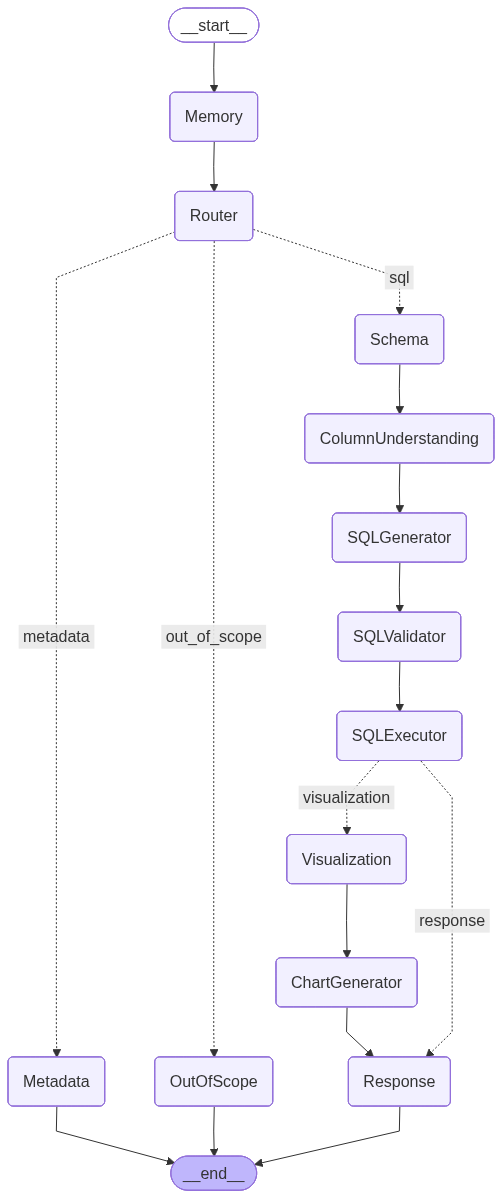

In [21]:
# =========================================================
# VISUALIZE AND SAVE GRAPH
# =========================================================

try:

    png_img = (
        graph.get_graph()
        .draw_mermaid_png()
    )

    with open(
        f"{TABLE_TITLE}_Analyser_Chatbot_Workflow.png",
        "wb"
    ) as f:

        f.write(png_img)

    console.print(
        "\n[bold green]Workflow PNG Saved Successfully[/bold green]"
    )

    console.print(
        f"File :{TABLE_TITLE}_Analyser_Chatbot_Workflow.png"
    )

    display(
        Image(
            png_img
        )
    )

except Exception as e:

    console.print(
        f"\n[bold red]Graph Visualization Failed:[/bold red] {e}"
    )

╭─────────────────────────────────────────────── Analyser Chatbot ────────────────────────────────────────────────╮
│ Welcome to Sample Sales Table Analyser Chatbot                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


Ask your question :  which manager performs best


Conversation Memory Agent Running

Memory Not Required

╭─────────────────────────────────────────────── Enhanced Question ───────────────────────────────────────────────╮
│ which manager performs best                                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

       Query Result Preview        
╔═════════╤════════╤══════════════╗
║ Manager │ Rating │ Product_Name ║
╟─────────┼────────┼──────────────╢
║ John    │ 4.5    │ Laptop       ║
║ Sarah   │ 4.2    │ Mobile       ║
║ Mike    │ 4.3    │ TV           ║
║ David   │ 4.0    │ AC           ║
║ John    │ 4.1    │ Fridge       ║
╚═════════╧════════╧══════════════╝

Visualization Agent Running

╭────────────────────────────────────────────── Visualization Plan ───────────────────────────────────────────────╮
│                                                                                                                 │
│ Chart Type : bar                                                                                                │
│                                                                                                                 │
│ X Axis : Manager                                                                                                │
│                                                                                                                 │
│ Y Axis : Rating                                                                                                 │
│                                                                                                                 │
│ Group By : Product_Name                                                                                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Chart Generator Agent Running

<Figure size 1200x600 with 0 Axes>

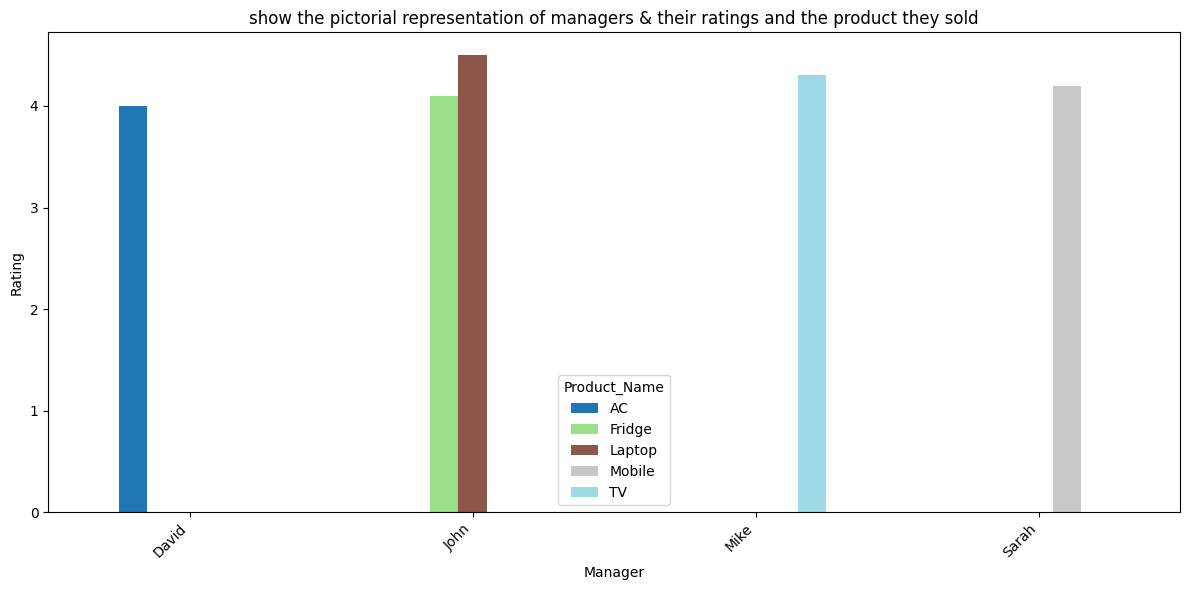

Chart Saved : Sample Sales Table_chart.png

Response Agent Running

╭───────────────────────────────────────────────── Final Answer ──────────────────────────────────────────────────╮
│ Manager  Rating Product_Name                                                                                    │
│    John     4.5       Laptop                                                                                    │
│   Sarah     4.2       Mobile                                                                                    │
│    Mike     4.3           TV                                                                                    │
│   David     4.0           AC                                                                                    │
│    John     4.1       Fridge                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


Ask your question :  what are the products sold in north


Conversation Memory Agent Running

...

   Query   
  Result   
  Preview  
╔═════════╗
║ Manager ║
╟─────────╢
║ John    ║
╚═════════╝

Response Agent Running

╭───────────────────────────────────────────────── Final Answer ──────────────────────────────────────────────────╮
│ John                                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


Ask your question :  bye


Exiting Sample Sales Table Analyser Chatbot

In [22]:
# =========================================================
# CHAT LOOP
# =========================================================

show_welcome_message()

chat_history = []

while True:

    user_question = input(
        "\nAsk your question : "
    ).strip()

    if user_question.lower() in [

        "exit",
        "quit",
        "bye"

    ]:

        console.print(
            f"\n[bold red]Exiting {TABLE_TITLE} Analyser Chatbot[/bold red]"
        )

        break

    try:

        result = graph.invoke({

            "question": user_question,

            "enhanced_question": "",

            "chat_history": chat_history,
           
            "query_type": "",
        
            "schema": "",
        
            "column_context": "",
        
            "sql_query": "",
        
            "is_visualization": False,
        
            "chart_type": "",
        
            "x_axis": "",
        
            "y_axis": "",
        
            "group_by": "",
        
            "chart_file": "",
        
            "result_df": pd.DataFrame(),
        
            "final_answer": ""
        
        })
        
        console.print(

            Panel(

                str(
                    result["final_answer"]
                ),

                title="Final Answer",

                border_style="green"

            )

        )

        chat_history.append({

            "question": user_question,

            "answer": result["final_answer"]

        })

    except Exception as e:

        console.print(

            Panel(

                str(e),

                title="Workflow Error",

                border_style="red"

            )

        )

### Testing Queries

1. which manager performs best

2. which category from which region sold less

3. what are the insights from the table

4. who is mj

5. what is the table all about

6. list the products available

7. show the pictorial representation of managers & their ratings and the product they sold

8. what are the products sold in north 

9. how much it has been sold

10. who sold them


file path: /Users/viswanathanmuthu/AI Course/Agentic AI Application/Talk2Table AI Applctn/sample_sales_table.csv